In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load DataSet

In [6]:
df = pd.read_csv('AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


In [7]:
df = pd.DataFrame(df)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.head()

,Open,High,Low,Close,Volume
0,0.128348,0.128906,0.128348,0.128348,469033600
1,0.122210,0.122210,0.121652,0.121652,175884800
2,0.113281,0.113281,0.112723,0.112723,105728000
3,0.115513,0.116071,0.115513,0.115513,86441600
4,0.118862,0.119420,0.118862,0.118862,73449600


In [8]:
df.shape

(10468, 5)

### Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, shuffle=False)

### Scalling

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [14]:
x_train_scaled = scaler.fit_transform(train)
x_test_scaled = scaler.transform(test)

In [15]:
def create_data(data):
    x = []
    y = []

    for i in range(60, len(data)):
        x.append(data[i-60:i])
        y.append(data[i, 3])

    return np.array(x), np.array(y)

In [16]:
x_train, y_train = create_data(x_train_scaled)
x_test, y_test = create_data(x_test_scaled)

### RNN Archeticture

In [17]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import SimpleRNN, BatchNormalization, Dropout, Dense

In [18]:
model = Sequential()

model.add(SimpleRNN(64, return_sequences = True, input_shape = (60, 5)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(SimpleRNN(32, return_sequences = True))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(SimpleRNN(16))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Output Layer
model.add(Dense(1, activation = 'linear'))

c:\Users\M Arshad\.conda\envs\deep\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Compilation

In [19]:
model.compile(optimizer = 'adam', loss='mse', metrics=[tf.keras.metrics.R2Score(name = 'r2_score')])

### Model Training

In [20]:
history = model.fit(x_train, y_train, epochs = 15, validation_data = (x_test, y_test))

Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - loss: 0.5140 - r2_score: -12.0698 - val_loss: 5.9600 - val_r2_score: -0.7959
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 0.1136 - r2_score: -1.6107 - val_loss: 6.2322 - val_r2_score: -0.8780
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - loss: 0.0811 - r2_score: -1.0187 - val_loss: 6.6455 - val_r2_score: -1.0025
Epoch 4/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 0.0461 - r2_score: -0.0840 - val_loss: 6.6504 - val_r2_score: -1.0040
Epoch 5/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - loss: 0.0353 - r2_score: 0.1841 - val_loss: 6.6131 - val_r2_score: -0.9928
Epoch 6/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 0.0213 - r2_score: 0.4966 - val_loss: 6.6485 - val_r2_score: -1.0034
Epoch 7/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0148 - r2_score: 0.6499 - val_loss: 6.9079 - val_r2_score: -1.0816
Epoch 8/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - loss: 0.0117 - r2_scor

## R2 Score

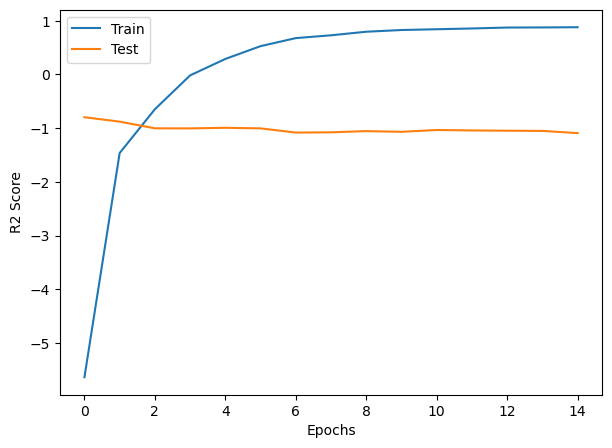

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['r2_score'], label='Train')
plt.plot(history.history['val_r2_score'], label='Test')
plt.xlabel('Epochs')
plt.ylabel('R2 Score')
plt.legend()
plt.show()

## Loss

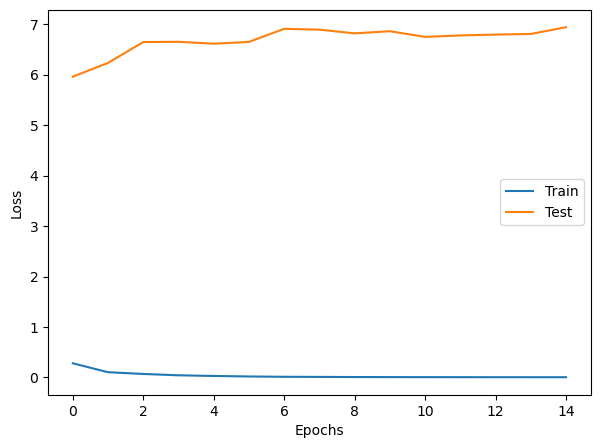

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model Performance

In [ ]:
# Today's data
today = [180, 185, 179, 183, 5000000]  # Open, High, Low, Close, Volume

# Take last 60 days
input_data = test.tail(60).values

# Replace the last day with today's data
input_data[-1] = today

# Scale
input_scaled = scaler.transform(input_data)
input_scaled = input_scaled.reshape(1, 60, 5)

prediction = model.predict(input_scaled)

# Convert prediction back to original price
close_min = scaler.data_min_[3]
close_max = scaler.data_max_[3]

predicted_close = prediction[0][0] * (close_max - close_min) + close_min
print("Predicted Next Day Close Price : ", predicted_close)

c:\Users\M Arshad\.conda\envs\deep\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Predicted Next Day Close Price :  20.096523203776716
